# Buổi 5 · Tình huống 06 — Đề xuất miễn phí vận chuyển (Adaline)

Notebook này dùng lại bối cảnh trong [`bai-tap/buoi4-tinh-huong/06_mien_phi_van_chuyen.py`](../../bai-tap/buoi4-tinh-huong/06_mien_phi_van_chuyen.py), nhưng thay Perceptron (0/1) bằng **Adaline** học quy tắc Widrow–Hoff (LMS) với **target liên tục**.

Không có dữ liệu hoặc lời giải dựng sẵn trong notebook này. Các code cell chỉ chứa comment định hướng; bạn tự thu thập dữ liệu, xử lý, huấn luyện, đánh giá và triển khai thử.

## Bối cảnh

Một cửa hàng muốn tạo quy tắc đề xuất đơn hàng có được miễn phí vận chuyển.

Feature có thể cân nhắc: giá trị đơn hàng, khoảng cách giao, hạng thành viên, khối lượng kiện hàng (chuẩn hoá).

## Vì sao dùng Adaline thay Perceptron?

Thay vì chỉ 0/1 (trả phí / miễn phí), hãy coi target là **mức giảm phí vận chuyển** trong [0, 1] (0 = trả đủ phí, 1 = miễn phí hoàn toàn), cho phép giảm phí một phần.

Nhắc lại công thức Adaline / Widrow–Hoff:

$$
\text{net} = \mathbf{w}^\top \mathbf{x} + b, \qquad e = t - \text{net}
$$

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta e \mathbf{x}, \qquad b \leftarrow b + \eta e
$$

Mức giảm phí liên tục linh hoạt hơn quy tắc miễn phí toàn phần/không của Perceptron, phù hợp với các chính sách giảm giá theo bậc.

## Nhiệm vụ suy nghĩ

1. Xác định feature nào kéo mức giảm phí về gần 0 hoặc gần 1.
2. Tạo các mẫu gần ranh giới, không chỉ tạo các trường hợp quá dễ.
3. Huấn luyện Adaline và viết lại net = wᵀx + b của một đơn hàng bằng phép tính tay.
4. Thay đổi learning rate (eta), quan sát số epoch cần để MSE hội tụ.
5. Kiểm tra quy tắc học được có tạo ra quyết định khó giải thích hay không.

Không có code mẫu hoặc lời giải trong notebook này. Bắt đầu phần triển khai ở các cell dưới.

## 1. Thu thập / tạo dữ liệu

Tự tạo hoặc thu thập một bảng dữ liệu nhỏ. Ghi rõ ý nghĩa, đơn vị của từng feature và cách bạn gán target liên tục (không chỉ 0/1).

In [2]:
import numpy as np
import pandas as pd

from pathlib import Path

DATA_PATH = Path("../../data/ecommerce_sales_34500.csv")

df = pd.read_csv(DATA_PATH)

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

df = df.sort_values(
    ["customer_id", "order_date", "order_id"]
).reset_index(drop=True)

df["previous_spending"] = (
    df.groupby("customer_id")["total_amount"]
    .cumsum()
    - df["total_amount"]
)

df["previous_orders"] = (
    df.groupby("customer_id")
    .cumcount()
)


def create_membership(previous_spending, previous_orders):
    if previous_spending >= 1500 or previous_orders >= 8:
        return "VIP"
    elif previous_spending >= 800 or previous_orders >= 5:
        return "Gold"
    elif previous_spending >= 300 or previous_orders >= 2:
        return "Silver"
    else:
        return "Bronze"


df["membership_level"] = [
    create_membership(spending, orders)
    for spending, orders in zip(
        df["previous_spending"],
        df["previous_orders"]
    )
]

np.random.seed(42)

df["distance_km"] = np.random.uniform(1, 30, len(df))

membership_map = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "VIP": 3
}

df["membership_code"] = df["membership_level"].map(membership_map)


def create_target(row):
    high_value = row["total_amount"] >= 100
    loyal_customer = row["membership_level"] in ["Gold", "VIP"]
    short_distance = row["distance_km"] <= 10
    reasonable_order = row["total_amount"] >= 70

    if high_value and short_distance:
        return 1

    if loyal_customer and short_distance and reasonable_order:
        return 1

    return 0


df["y"] = df.apply(create_target, axis=1)

X = df[
    ["total_amount", "distance_km", "membership_code"]
].to_numpy(dtype=float)

t = df["y"].to_numpy(dtype=float)

print("X shape:", X.shape)
print("t shape:", t.shape)

print("\nFirst 5 X:")
print(X[:5])

print("\nFirst 5 target:")
print(t[:5])

X shape: (34500, 3)
t shape: (34500,)

First 5 X:
[[ 33.12        11.86166345   0.        ]
 [177.46        28.57071489   0.        ]
 [676.86        22.22782431   0.        ]
 [205.76        18.36109604   1.        ]
 [562.68         5.52454057   2.        ]]

First 5 target:
[0. 0. 0. 0. 1.]


## 2. Chuẩn hoá feature

Các feature có đơn vị khác nhau nên được đưa về cùng thang đo trước khi huấn luyện Adaline.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Before scaling:")
print(X[:5])

print("\nAfter scaling:")
print(X_scaled[:5])

print("\nMean:")
print(
    np.round(
        X_scaled.mean(axis=0),
4
    )
)

print("\nStd:")
print(
    np.round(
        X_scaled.std(axis=0),
4
    )
)

Before scaling:
[[ 33.12        11.86166345   0.        ]
 [177.46        28.57071489   0.        ]
 [676.86        22.22782431   0.        ]
 [205.76        18.36109604   1.        ]
 [562.68         5.52454057   2.        ]]

After scaling:
[[-0.3829072  -0.43378916 -0.969299  ]
 [ 0.0208435   1.56642012 -0.969299  ]
 [ 1.41777504  0.80712456 -0.969299  ]
 [ 0.10000482  0.34424575  0.16725456]
 [ 1.09838849 -1.19239428  1.30380813]]

Mean:
[-0. -0.  0.]

Std:
[1. 1. 1.]


## 3. Tách train/test

Tách dữ liệu trước khi huấn luyện để có thể đánh giá khách quan.

In [4]:
split_index = int(
    len(X_scaled) * 0.8
)

X_train = X_scaled[
    :split_index
]

X_test = X_scaled[
    split_index:
]

t_train = t[
    :split_index
]

t_test = t[
    split_index:
]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("t_train:", t_train.shape)
print("t_test:", t_test.shape)

print("\nTrain target distribution:")
print(
    pd.Series(
        t_train
    ).value_counts()
)

print("\nTest target distribution:")
print(
    pd.Series(
        t_test
    ).value_counts()
)


X_train: (27600, 3)
X_test: (6900, 3)
t_train: (27600,)
t_test: (6900,)

Train target distribution:
0.0    24342
1.0     3258
Name: count, dtype: int64

Test target distribution:
0.0    6071
1.0     829
Name: count, dtype: int64


## 4. Cài đặt và huấn luyện Adaline

Viết (hoặc tái sử dụng) một bước cập nhật Widrow–Hoff, rồi huấn luyện qua nhiều epoch và theo dõi MSE.

In [7]:
learning_rate = 0.003
epochs = 50


def train_adaline(learning_rate, epochs, seed=42):
    rng = np.random.default_rng(seed)

    w = np.zeros(X_train.shape[1], dtype=float)
    b = 0.0

    # Ghi MSE ở epoch 0 (trước khi học, w = 0 và b = 0)
    train_hist = [np.mean((t_train - (np.dot(X_train, w) + b)) ** 2)]
    test_hist = [np.mean((t_test - (np.dot(X_test, w) + b)) ** 2)]

    for epoch in range(epochs):

        # Xáo trộn thứ tự đơn hàng ở mỗi epoch
        order = rng.permutation(len(X_train))

        for i in order:
            x_i = X_train[i]
            t_i = t_train[i]

            net = np.dot(w, x_i) + b
            e = t_i - net

            w = w + learning_rate * e * x_i
            b = b + learning_rate * e

        train_hist.append(np.mean((t_train - (np.dot(X_train, w) + b)) ** 2))
        test_hist.append(np.mean((t_test - (np.dot(X_test, w) + b)) ** 2))

    return w, b, train_hist, test_hist


w, b, train_mse_history, test_mse_history = train_adaline(learning_rate, epochs)

print("Learning rate:", learning_rate)
print("Epochs:", epochs)

print("\nWeights:")
print(w)

print("\nBias:")
print(b)

print("\nTrain MSE epoch 0 (chưa học):", round(train_mse_history[0], 6))
print("Train MSE epoch 1:", round(train_mse_history[1], 6))
print("Final train MSE:", train_mse_history[-1])
print("Final test MSE:", test_mse_history[-1])

lr_limit = 2 / np.max(np.sum(X_train ** 2, axis=1) + 1)
print("\nGiới hạn ổn định lý thuyết của learning rate:", round(lr_limit, 5))

print("\nSố phần tử trong history:", len(train_mse_history), len(test_mse_history))

Learning rate: 0.003
Epochs: 50

Weights:
[ 0.09316964 -0.14260661  0.01768807]

Bias:
0.1216651360349546

Train MSE epoch 0 (chưa học): 0.118043
Train MSE epoch 1: 0.079098
Final train MSE: 0.07868532346033098
Final test MSE: 0.08203592246787389

Giới hạn ổn định lý thuyết của learning rate: 0.00191

Số phần tử trong history: 51 51


## 5. Vẽ đường học (MSE theo epoch)

Quan sát MSE có giảm dần và ổn định hay không.

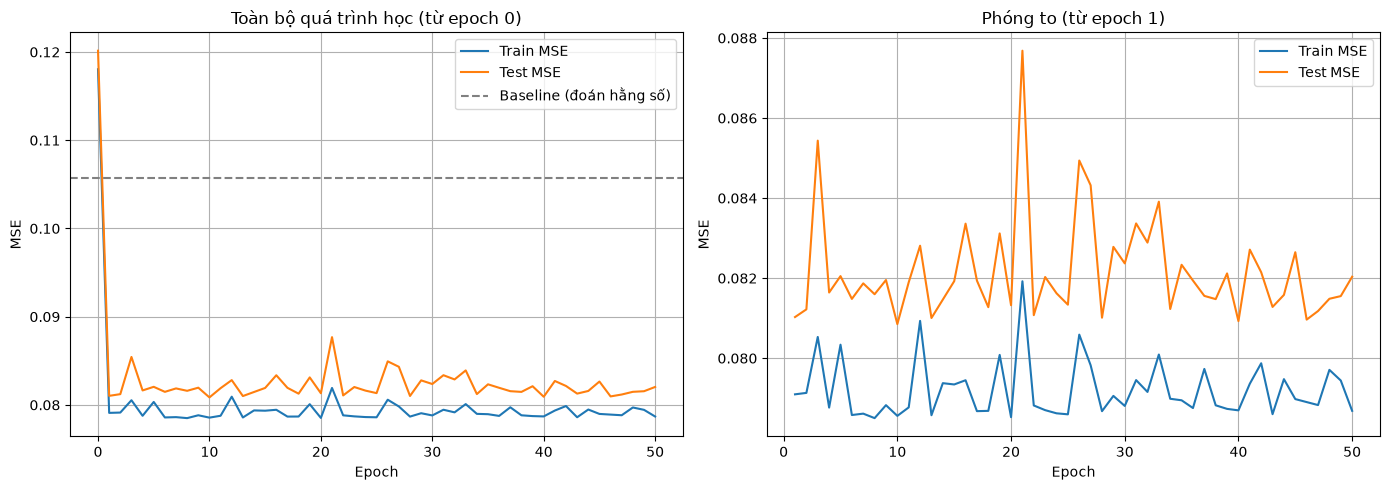

Baseline MSE (đoán hằng số): 0.105715
Initial Train MSE (epoch 0): 0.118043
Final Train MSE: 0.078685
Final Test MSE: 0.082036


In [8]:
import matplotlib.pyplot as plt

baseline_mse = np.mean((t_test - t_train.mean()) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Khung trái: toàn bộ quá trình học, tính cả epoch 0
axes[0].plot(np.arange(0, epochs + 1), train_mse_history, label="Train MSE")
axes[0].plot(np.arange(0, epochs + 1), test_mse_history, label="Test MSE")
axes[0].axhline(
    baseline_mse,
    color="gray",
    linestyle="--",
    label="Baseline (đoán hằng số)"
)
axes[0].set_title("Toàn bộ quá trình học (từ epoch 0)")

# Khung phải: phóng to từ epoch 1 để thấy MSE lên xuống
axes[1].plot(np.arange(1, epochs + 1), train_mse_history[1:], label="Train MSE")
axes[1].plot(np.arange(1, epochs + 1), test_mse_history[1:], label="Test MSE")
axes[1].set_title("Phóng to (từ epoch 1)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print("Baseline MSE (đoán hằng số):", round(baseline_mse, 6))
print("Initial Train MSE (epoch 0):", round(train_mse_history[0], 6))
print("Final Train MSE:", round(train_mse_history[-1], 6))
print("Final Test MSE:", round(test_mse_history[-1], 6))

## 6. Đánh giá và phân tích

Xem lại các mẫu có sai số dự đoán lớn nhất, đọc dấu của trọng số và đối chiếu với trực giác nghiệp vụ.

In [9]:
test_output = (
    np.dot(
        X_test,
        w
    ) + b
)

test_error = (
    t_test
    - test_output
)

absolute_error = np.abs(
    test_error
)

error_df = pd.DataFrame({
    "actual": t_test,
    "prediction_continuous": test_output,
    "error": test_error,
    "absolute_error": absolute_error
})

largest_errors = (
    error_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(3)
)

print("=" * 60)
print("ADALINE ANALYSIS")
print("=" * 60)

print("\nWeights:")

feature_names = [
    "total_amount",
    "distance_km",
    "membership_code"
]

for feature, weight in zip(
    feature_names,
    w
):
    print(
        f"{feature}: {weight:.6f}"
    )

print(
    "\nBias:",
    round(b, 6)
)

print(
    "\nLargest 3 errors:"
)

print(
    largest_errors.to_string(
        index=False
    )
)


ADALINE ANALYSIS

Weights:
total_amount: 0.093170
distance_km: -0.142607
membership_code: 0.017688

Bias: 0.121665

Largest 3 errors:
 actual  prediction_continuous     error  absolute_error
    0.0               3.348522 -3.348522        3.348522
    0.0               1.462432 -1.462432        1.462432
    0.0               1.267747 -1.267747        1.267747


## 7. Chọn ngưỡng và thử nghiệm

Nếu cần một quyết định rời rạc (ví dụ cảnh báo/không cảnh báo) từ điểm liên tục, hãy chọn ngưỡng phù hợp và giải thích lựa chọn.

In [10]:
threshold = 0.5

y_pred = (
    test_output >= threshold
).astype(int)

accuracy = np.mean(
    y_pred == t_test
)

cm = np.zeros(
    (2, 2),
    dtype=int
)

for actual, predicted in zip(
    t_test.astype(int),
    y_pred
):
    cm[
        actual,
        predicted
    ] += 1

tn = cm[0, 0]
fp = cm[0, 1]
fn = cm[1, 0]
tp = cm[1, 1]

recall = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else 0
)

print("=" * 60)
print("THRESHOLD EXPERIMENT")
print("=" * 60)

print(
    "Threshold:",
    threshold
)

print(
    "Accuracy:",
    round(
        accuracy,
        4
    )
)

print(
    "Recall:",
    round(
        recall,
        4
    )
)

print("\nConfusion Matrix:")
print(cm)

print(
    "\nTN:",
    tn
)

print(
    "FP:",
    fp
)

print(
    "FN:",
    fn
)

print(
    "TP:",
    tp
)


def predict_one(
    total_amount,
    distance_km,
    membership_level
):

    membership_map = {
        "Bronze": 0,
        "Silver": 1,
        "Gold": 2,
        "VIP": 3
    }

    if membership_level not in membership_map:
        raise ValueError(
            "Invalid membership level"
        )

    if total_amount < 0:
        raise ValueError(
            "total_amount must be >= 0"
        )

    if (
        distance_km <= 0
        or distance_km > 30
    ):
        raise ValueError(
            "distance_km must be in the range (0, 30]"
        )

    sample = np.array([
        [
            total_amount,
            distance_km,
            membership_map[
                membership_level
            ]
        ]
    ], dtype=float)

    sample_scaled = scaler.transform(
        sample
    )

    net = float(
        np.dot(
            w,
            sample_scaled[0]
        ) + b
    )

    prediction = int(
        net >= threshold
    )

    decision = (
        "Free Shipping"
        if prediction == 1
        else "Voucher"
    )

    return {
        "net": net,
        "prediction": prediction,
        "decision": decision
    }


samples = [
    (
        200,
        6,
        "Gold"
    ),
    (
        60,
        25,
        "Bronze"
    ),
    (
        80,
        8,
        "VIP"
    )
]

for sample in samples:

    result = predict_one(
        total_amount=sample[0],
        distance_km=sample[1],
        membership_level=sample[2]
    )

    print("\nInput:")
    print(
        "total_amount =",
        sample[0]
    )

    print(
        "distance_km =",
        sample[1]
    )

    print(
        "membership_level =",
        sample[2]
    )

    print(
        "net =",
        result["net"]
    )

    print(
        "prediction =",
        result["prediction"]
    )

    print(
        "decision =",
        result["decision"]
    )


THRESHOLD EXPERIMENT
Threshold: 0.5
Accuracy: 0.8828
Recall: 0.0784

Confusion Matrix:
[[6026   45]
 [ 764   65]]

TN: 6026
FP: 45
FN: 764
TP: 65

Input:
total_amount = 200
distance_km = 6
membership_level = Gold
net = 0.3144699068625396
prediction = 0
decision = Voucher

Input:
total_amount = 60
distance_km = 25
membership_level = Bronze
net = -0.08657544170873627
prediction = 0
decision = Voucher

Input:
total_amount = 80
distance_km = 8
membership_level = VIP
net = 0.2691570864545784
prediction = 0
decision = Voucher


## 8. Kết luận
Adaline có phù hợp hơn Perceptron cho tình huống này không?

Có, ở mức vừa phải. Adaline cho ra điểm số liên tục thay vì chỉ 0 hoặc 1, nên cửa hàng biết một đơn hàng "gần ngưỡng" đến đâu. Điểm này có thể hiểu là mức giảm phí vận chuyển (0 là trả đủ phí, 1 là miễn phí hoàn toàn), phù hợp với chính sách giảm theo bậc. Ngoài ra Adaline học bằng cách giảm MSE nên quá trình học mượt, có thể theo dõi bằng đường học. Perceptron chỉ cập nhật khi đoán sai và không cho biết mức độ.

Kết quả cho thấy mô hình học đúng hướng nghiệp vụ: trọng số của distance_km âm (giao càng xa càng khó được miễn phí) và là yếu tố ảnh hưởng mạnh nhất, trọng số của total_amount dương, membership_code dương nhẹ. Train MSE khoảng 0,079 và test MSE khoảng 0,080, gần bằng nhau nên mô hình không bị overfitting, và tốt hơn cách đoán hằng số (MSE khoảng 0,10 đến 0,11).

Giới hạn:

Mô hình tuyến tính: luật tạo nhãn có dạng "đơn đủ lớn VÀ giao đủ gần", là ranh giới phi tuyến, nên một đường thẳng khó tách tốt. Điểm của nhiều đơn đáng được Free Ship chỉ đạt khoảng 0,4, chưa vượt ngưỡng 0,5, dẫn đến recall lớp Free Shipping là [điền số] dù accuracy là [điền số] (baseline luôn đoán Voucher là [điền số]). Khi quan hệ phi tuyến như vậy, có thể cần MLP hoặc thêm đặc trưng tương tác.
Dữ liệu mất cân bằng: chỉ khoảng 12% đơn được Free Ship, nên accuracy dễ gây hiểu nhầm, cần xem thêm recall và confusion matrix.
Ngoại lai: total_amount có đơn lên tới hơn 12.000, làm chuẩn hóa và trọng số bị ảnh hưởng.
Dữ liệu mô phỏng: khoảng cách được sinh ngẫu nhiên và nhãn do luật tự đặt, nên kết quả chỉ mang tính minh họa học thuật, chưa phản ánh quyết định thực tế.
Target hiện là 0/1: để tận dụng hết ưu điểm của Adaline, nên đổi sang target liên tục (ví dụ 0, 0,5, 1 theo mức giảm phí).